In [ ]:
# ── Cell 1: Install & Import Dependencies ─────────────────────────────────
!pip install -q requests plotly kaleido streamlit pyngrok openpyxl seaborn

import warnings, time, random, os, logging, io, threading, subprocess, json
from datetime import datetime
from collections import deque
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics import (confusion_matrix, classification_report,
                              accuracy_score, precision_score,
                              recall_score, f1_score)

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns

import requests
from google.colab import files
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets

logging.basicConfig(level=logging.INFO,
                    format='%(asctime)s | %(levelname)s | %(message)s')
logger = logging.getLogger(__name__)

print('Dependencies loaded successfully')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 45.2 MB/s eta 0:00:00
Dependencies loaded successfully


In [ ]:
# ── Cell 2: Upload Dataset ────────────────────────────────────────────────
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df_raw = pd.read_csv(io.BytesIO(uploaded[filename]))
print(f'Loaded {len(df_raw):,} rows x {df_raw.shape[1]} columns from "{filename}"')
df_raw.head(3)


Saving iiot_smart_grid_dataset.csv to iiot_smart_grid_dataset.csv
Loaded 8,737 rows x 20 columns from "iiot_smart_grid_dataset.csv"


,Timestamp,Power_Consumption_kWh,Voltage_V,Current_A,Power_Factor,Grid_Frequency_Hz,Reactive_Power_kVAR,Active_Power_kW,Demand_Response_Event,Temperature_C,Humidity_%,Weather_Condition,Solar_Power_Generation_kW,Wind_Power_Generation_kW,Previous_Day_Consumption_kWh,Peak_Load_Hour,Energy_Source_Type,User_Type,Normalized_Consumption,Energy_Efficiency_Score
0,01-01-2023 00:00,2.185431,213.199299,7.508245,0.889422,50.233661,4.116021,1.656607,0,21.450547,36.131842,Sunny,1.686532,1.801124,4.136763,1,3,1,0.374639,56.494791
1,01-01-2023 01:00,4.778214,213.593030,1.415176,0.864647,50.118395,3.028259,3.462097,0,7.275757,71.159012,Rainy,2.957409,0.301453,2.025722,0,1,2,0.950982,36.038133
2,01-01-2023 02:00,3.793973,233.630149,7.840398,0.802709,49.585861,0.927931,1.043200,0,26.114876,56.737634,Sunny,1.770425,0.603941,0.950256,1,3,1,0.732198,31.316131


In [ ]:
# ── Cell 3: Configuration ─────────────────────────────────────────────────
# =========================================================================
#  EDIT THIS BLOCK — everything else runs automatically
# =========================================================================

TELEGRAM_TOKEN   = '8790701322:AAGgrp93eRbD7hH4vRUXLXiAXi_TgwCLoiA'   # e.g. '7123456789:AAF...'
TELEGRAM_CHAT_ID = '6068489685'   # e.g. '-100123456789'
NGROK_AUTH_TOKEN = '3BlUHAvdxBWy8iewcHWaDJfWuUT_6PARJYmjg4BSnLLqCgPb6'   # Get free token at https://ngrok.com

# ── Rule-based thresholds ──────────────────────────────────────────────────
THRESHOLDS = {
    'voltage_high'     : 250.0,   # V
    'voltage_low'      : 210.0,   # V
    'current_high'     : 90.0,    # A
    'power_factor_low' : 0.85,
    'temp_high'        : 40.0,    # deg C
    'freq_high'        : 50.5,    # Hz
    'freq_low'         : 49.5,    # Hz
    'reactive_high'    : 50.0,    # kVAR
}

# ── ML model settings ──────────────────────────────────────────────────────
ISOLATION_FOREST_CONTAMINATION = 0.05
OCSVM_NU                       = 0.05
SIMULATION_DELAY_SECONDS       = 0.05
SIMULATION_STEPS               = 100

# ── Noise injection ────────────────────────────────────────────────────────
ADD_SENSOR_NOISE    = True
INJECT_ANOMALIES    = True
ANOMALY_INJECT_RATE = 0.03

# ── Telegram alert buffer ─────────────────────────────────────────────────
TELEGRAM_BUFFER_SECONDS = 10   # batch alerts within this window

# ── Alert log paths ───────────────────────────────────────────────────────
ALERT_LOG_CSV  = 'alerts_log.csv'
ALERT_LOG_XLSX = 'alerts_log.xlsx'

print('Configuration saved')


Configuration saved


In [ ]:
# ── Cell 4: Data Preprocessing & 30-Minute Resampling ────────────────────
def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], dayfirst=True, errors='coerce')
    df = df.dropna(subset=['Timestamp'])
    df = df.set_index('Timestamp').sort_index()
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    df[numeric_cols] = df[numeric_cols].interpolate(method='time').ffill().bfill()
    df_30 = df[numeric_cols].resample('30min').interpolate(method='time')
    if 'Weather_Condition' in df.columns:
        df_30['Weather_Condition'] = df['Weather_Condition'].resample('30min').ffill()
    return df_30

df = preprocess(df_raw)
print(f'Preprocessed: {len(df):,} rows at 30-min resolution')
print(f' Date range : {df.index.min()} to {df.index.max()}')
display(df.head(5))


Preprocessed: 17,473 rows at 30-min resolution
 Date range : 2023-01-01 00:00:00 to 2023-12-31 00:00:00


,Power_Consumption_kWh,Voltage_V,Current_A,Power_Factor,Grid_Frequency_Hz,Reactive_Power_kVAR,Active_Power_kW,Demand_Response_Event,Temperature_C,Humidity_%,Solar_Power_Generation_kW,Wind_Power_Generation_kW,Previous_Day_Consumption_kWh,Peak_Load_Hour,Energy_Source_Type,User_Type,Normalized_Consumption,Energy_Efficiency_Score,Weather_Condition
Timestamp,,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,2.185431,213.199299,7.508245,0.889422,50.233661,4.116021,1.656607,0.0,21.450547,36.131842,1.686532,1.801124,4.136763,1.0,3.0,1.0,0.374639,56.494791,Sunny
2023-01-01 00:30:00,3.481822,213.396165,4.461711,0.877034,50.176028,3.572140,2.559352,0.0,14.363152,53.645427,2.321970,1.051289,3.081242,0.5,2.0,1.5,0.662810,46.266462,Sunny
2023-01-01 01:00:00,4.778214,213.593030,1.415176,0.864647,50.118395,3.028259,3.462097,0.0,7.275757,71.159012,2.957409,0.301453,2.025722,0.0,1.0,2.0,0.950982,36.038133,Rainy
2023-01-01 01:30:00,4.286094,223.611589,4.627787,0.833678,49.852128,1.978095,2.252648,0.0,16.695317,63.948323,2.363917,0.452697,1.487989,0.5,2.0,1.5,0.841590,33.677132,Rainy
2023-01-01 02:00:00,3.793973,233.630149,7.840398,0.802709,49.585861,0.927931,1.043200,0.0,26.114876,56.737634,1.770425,0.603941,0.950256,1.0,3.0,1.0,0.732198,31.316131,Sunny


In [ ]:
# ── Cell 5: Half-Hourly Analytics Aggregation ────────────────────────────
def compute_halfhour_analytics(df: pd.DataFrame) -> pd.DataFrame:
    agg = pd.DataFrame(index=df.index)
    agg['Mean_Voltage_V']      = df['Voltage_V']
    agg['Mean_Current_A']      = df['Current_A']
    agg['Mean_Temperature_C']  = df['Temperature_C']
    agg['Mean_PowerFactor']    = df['Power_Factor']
    agg['Mean_Frequency_Hz']   = df['Grid_Frequency_Hz']
    agg['Total_Energy_kWh']    = df['Power_Consumption_kWh']
    agg['Active_Power_kW']     = df['Active_Power_kW']
    agg['Reactive_Power_kVAR'] = df['Reactive_Power_kVAR']
    agg['Solar_kW']            = df['Solar_Power_Generation_kW']
    agg['Wind_kW']             = df['Wind_Power_Generation_kW']
    agg['Renewable_Total_kW']  = agg['Solar_kW'] + agg['Wind_kW']
    agg['Renewable_Fraction']  = (
        agg['Renewable_Total_kW'] /
        (agg['Active_Power_kW'].replace(0, np.nan))
    ).clip(0, 1).fillna(0)
    agg['Apparent_Power_kVA']  = np.sqrt(
        df['Active_Power_kW']**2 + df['Reactive_Power_kVAR']**2
    )
    agg['Efficiency_Score'] = df['Energy_Efficiency_Score']
    return agg

analytics = compute_halfhour_analytics(df)
print(f' Analytics table: {analytics.shape}')
display(analytics.describe().T[['mean','std','min','max']].round(3))


 Analytics table: (17473, 14)


,mean,std,min,max
Mean_Voltage_V,230.041,10.012,210.002,249.997
Mean_Current_A,10.643,4.738,1.001,19.998
Mean_Temperature_C,17.488,11.161,-4.994,39.994
Mean_PowerFactor,0.899,0.050,0.800,1.000
Mean_Frequency_Hz,49.999,0.251,49.500,50.500
Total_Energy_kWh,2.724,1.121,0.500,4.999
Active_Power_kW,2.501,0.993,0.500,4.500
Reactive_Power_kVAR,2.545,1.227,0.100,5.000
Solar_kW,1.505,0.746,0.001,3.000
Wind_kW,1.253,0.625,0.001,2.500


In [ ]:
# ── Cell 6: Alert Detection System (Rule-based + Statistical) ────────────

# One-liner suggested fixes per alert type
SUGGESTED_FIXES = {
    'Over-Voltage'          : 'Reduce load on feeder or adjust transformer tap setting.',
    'Under-Voltage'         : 'Increase reactive power support or check line losses.',
    'Over-Current'          : 'Trip non-critical loads immediately; inspect for short circuits.',
    'Low Power Factor'      : 'Install capacitor banks or VAR compensators on the feeder.',
    'Over-Temperature'      : 'Increase cooling airflow or reduce equipment loading.',
    'High Frequency'        : 'Reduce generation output or increase load shedding.',
    'Low Frequency'         : 'Dispatch more generation reserves or reduce load.',
    'High Reactive Power'   : 'Add shunt capacitors or reduce inductive load.',
    'Statistical Anomaly'   : 'Investigate sensor calibration and check for equipment faults.',
    'ML Anomaly'            : 'Perform manual inspection; cross-check all sensor readings.',
}

event_log: list = []

def get_fix(alert_type: str) -> str:
    for key, fix in SUGGESTED_FIXES.items():
        if key.lower() in alert_type.lower():
            return fix
    return 'Check equipment and sensor readings for abnormalities.'

def log_event(timestamp, parameter, value, alert_type, severity, source='rule'):
    event_log.append({
        'Timestamp'     : timestamp,
        'Parameter'     : parameter,
        'Value'         : round(float(value), 4),
        'Alert_Type'    : alert_type,
        'Severity'      : severity,
        'Source'        : source,
        'Suggested_Fix' : get_fix(alert_type),
        'Logged_At'     : datetime.now().isoformat(),
    })

def rule_based_check(row: pd.Series, ts) -> list:
    alerts = []
    T = THRESHOLDS
    checks = [
        ('Voltage_V',           row['Voltage_V'] > T['voltage_high'],            'Over-Voltage',        'HIGH'),
        ('Voltage_V',           row['Voltage_V'] < T['voltage_low'],             'Under-Voltage',       'HIGH'),
        ('Current_A',           row['Current_A'] > T['current_high'],            'Over-Current',        'CRITICAL'),
        ('Power_Factor',        row['Power_Factor'] < T['power_factor_low'],     'Low Power Factor',    'MEDIUM'),
        ('Temperature_C',       row['Temperature_C'] > T['temp_high'],           'Over-Temperature',    'HIGH'),
        ('Grid_Frequency_Hz',   row['Grid_Frequency_Hz'] > T['freq_high'],       'High Frequency',      'MEDIUM'),
        ('Grid_Frequency_Hz',   row['Grid_Frequency_Hz'] < T['freq_low'],        'Low Frequency',       'MEDIUM'),
        ('Reactive_Power_kVAR', row['Reactive_Power_kVAR'] > T['reactive_high'], 'High Reactive Power', 'LOW'),
    ]
    for param, condition, alert_name, severity in checks:
        if condition:
            alerts.append({'ts': ts, 'param': param, 'val': row[param],
                           'type': alert_name, 'severity': severity, 'source': 'rule'})
            log_event(ts, param, row[param], alert_name, severity, source='rule')
    return alerts

def statistical_check(row: pd.Series, ts, stats: dict) -> list:
    alerts = []
    for col, (mean, std) in stats.items():
        if std == 0:
            continue
        z = (row[col] - mean) / std
        if abs(z) > 3:
            atype = f'Statistical Anomaly (z={z:.1f})'
            alerts.append({'ts': ts, 'param': col, 'val': row[col],
                           'type': atype, 'severity': 'MEDIUM', 'source': 'statistical'})
            log_event(ts, col, row[col], atype, 'MEDIUM', source='statistical')
    return alerts

STAT_COLS = ['Voltage_V', 'Current_A', 'Temperature_C', 'Grid_Frequency_Hz', 'Power_Factor']
col_stats = {c: (df[c].mean(), df[c].std()) for c in STAT_COLS}

print(' Rule-based & statistical alert system ready')
print(f'   Monitoring : {list(THRESHOLDS.keys())}')
print(f'   Fix library: {len(SUGGESTED_FIXES)} entries')


 Rule-based & statistical alert system ready
   Monitoring : ['voltage_high', 'voltage_low', 'current_high', 'power_factor_low', 'temp_high', 'freq_high', 'freq_low', 'reactive_high']
   Fix library: 10 entries


In [ ]:
# ── Cell 7: Machine Learning Module (Isolation Forest + One-Class SVM) ───
ML_FEATURES = [
    'Voltage_V', 'Current_A', 'Power_Factor', 'Grid_Frequency_Hz',
    'Temperature_C', 'Active_Power_kW', 'Reactive_Power_kVAR',
    'Power_Consumption_kWh', 'Solar_Power_Generation_kW',
    'Wind_Power_Generation_kW'
]

X = df[ML_FEATURES].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Isolation Forest
iso_forest = IsolationForest(
    contamination=ISOLATION_FOREST_CONTAMINATION,
    random_state=42, n_estimators=200
)
iso_forest.fit(X_scaled)
df['IF_Score']   = -iso_forest.score_samples(X_scaled)
df['IF_Anomaly'] =  iso_forest.predict(X_scaled)

# One-Class SVM
n_train = min(2000, len(X_scaled))
ocsvm = OneClassSVM(nu=OCSVM_NU, kernel='rbf', gamma='scale')
ocsvm.fit(X_scaled[:n_train])
df['OCSVM_Anomaly'] = ocsvm.predict(X_scaled)

# Ensemble (AND gate): flag only when BOTH models agree
df['Ensemble_Anomaly'] = (
    (df['IF_Anomaly'] == -1) & (df['OCSVM_Anomaly'] == -1)
).astype(int)

n_if  = (df['IF_Anomaly']    == -1).sum()
n_svm = (df['OCSVM_Anomaly'] == -1).sum()
n_ens =  df['Ensemble_Anomaly'].sum()

print(f' ML models trained on {len(X_scaled):,} samples')
print(f'   Isolation Forest  : {n_if:,} anomalies ({n_if/len(df)*100:.1f}%)')
print(f'   One-Class SVM     : {n_svm:,} anomalies ({n_svm/len(df)*100:.1f}%)')
print(f'   Ensemble (AND)    : {n_ens:,} anomalies ({n_ens/len(df)*100:.1f}%)')

# Log ML ensemble anomalies to event log
for ts, row in df[df['Ensemble_Anomaly'] == 1].iterrows():
    log_event(ts, 'Ensemble-ML', row['IF_Score'],
              'ML Anomaly (IF+OCSVM)', 'HIGH', source='ML')


 ML models trained on 17,473 samples
   Isolation Forest  : 874 anomalies (5.0%)
   One-Class SVM     : 1,387 anomalies (7.9%)
   Ensemble (AND)    : 787 anomalies (4.5%)


In [ ]:
# ── Cell 8: Telegram Notification System (10-s buffer + fix hints) ────────

# Severity emojis — clear, human-readable
SEVERITY_EMOJI = {
    'CRITICAL': '🔴',
    'HIGH':     '🟠',
    'MEDIUM':   '🟡',
    'LOW':      '🟢',
}

# Parameter display names + units
PARAM_META = {
    'Voltage_V':             ('⚡ Voltage',         'V'),
    'Current_A':             ('🔌 Current',          'A'),
    'Power_Factor':          ('📐 Power Factor',   ''),
    'Grid_Frequency_Hz':     ('〰️ Grid Frequency',  'Hz'),
    'Temperature_C':         ('🌡️ Temperature',     '°C'),
    'Active_Power_kW':       ('💡 Active Power',    'kW'),
    'Reactive_Power_kVAR':   ('🔄 Reactive Power',  'kVAR'),
    'Power_Consumption_kWh': ('🔋 Energy',           'kWh'),
    'Solar_Power_Generation_kW':  ('☀️ Solar Gen',   'kW'),
    'Wind_Power_Generation_kW':   ('💨 Wind Gen',    'kW'),
    'Ensemble_ML':           ('🤖 ML Model',         ''),
}

def _fmt_param(raw: str) -> str:
    meta = PARAM_META.get(raw)
    return meta[0] if meta else print(f"📊 {raw.replace('_', ' ')}")

def _fmt_unit(raw: str) -> str:
    meta = PARAM_META.get(raw)
    return meta[1] if meta else ""

# ── Alert CSV/Excel logger ─────────────────────────────────────────────────
_CSV_COLS = [
    'Sent_At', 'Timestamp', 'Parameter', 'Value',
    'Alert_Type', 'Severity', 'Source', 'Suggested_Fix', 'Telegram_Sent'
]

def _ensure_alert_log():
    if not os.path.exists(ALERT_LOG_CSV):
        pd.DataFrame(columns=_CSV_COLS).to_csv(ALERT_LOG_CSV, index=False)

def _append_to_alert_log(alert: dict, sent: bool):
    _ensure_alert_log()
    row = {
        'Sent_At'       : datetime.now().isoformat(),
        'Timestamp'     : str(alert.get('ts', '')),
        'Parameter'     : alert.get('param', ''),
        'Value'         : round(float(alert.get('val', 0)), 4),
        'Alert_Type'    : alert.get('type', ''),
        'Severity'      : alert.get('severity', ''),
        'Source'        : alert.get('source', 'unknown'),
        'Suggested_Fix' : get_fix(alert.get('type', '')),
        'Telegram_Sent' : sent,
    }
    pd.DataFrame([row]).to_csv(ALERT_LOG_CSV, mode='a', header=False, index=False)

_ensure_alert_log()
print(f' Alert log initialised → {ALERT_LOG_CSV}')

# ── Raw Telegram sender ────────────────────────────────────────────────────
def _send_telegram_raw(message: str) -> bool:
    if not TELEGRAM_TOKEN or not TELEGRAM_CHAT_ID:
        return False
    url = f'https://api.telegram.org/bot{TELEGRAM_TOKEN}/sendMessage'
    try:
        r = requests.post(url, json={'chat_id': TELEGRAM_CHAT_ID,
                                     'text': message, 'parse_mode': 'Markdown'},
                          timeout=5)
        return r.status_code == 200
    except Exception as e:
        logger.warning(f'Telegram error: {e}')
        return False

def _format_single(alert: dict) -> str:
    sev    = alert.get('severity', 'MEDIUM')
    emoji  = SEVERITY_EMOJI.get(sev, '⚪')
    param  = alert.get('param', '')
    val    = float(alert.get('val', 0))
    unit   = _fmt_unit(param)
    pname  = _fmt_param(param)
    atype  = alert.get('type', 'Unknown')
    fix    = get_fix(atype)
    ts_raw = str(alert.get('ts', ''))
    src    = alert.get('source', 'rule').upper()
    val_str = f'{val:.3f} {unit}'.strip()
    return (
        f"{emoji} *SMART GRID ALERT — {sev}*\n"
        f"━━━━━━━━━━━━━━━━━━━━━━\n"
        f"📍 *What happened:* {atype}\n"
        f"📊 *Parameter:* {pname}\n"
        f"📈 *Measured value:* `{val_str}`\n"
        f"🕐 *Time:* `{ts_raw}`\n"
        f"🔍 *Detected by:* {src}\n"
        f"━━━━━━━━━━━━━━━━━━━━━━\n"
        f"🛠️ *What to do:*\n_{fix}_"
    )

def _format_batch(batch: list) -> str:
    n   = len(batch)
    now = datetime.now().strftime('%H:%M:%S')
    sev_counts = {}
    for a in batch:
        s = a.get('severity', 'MEDIUM')
        sev_counts[s] = sev_counts.get(s, 0) + 1
    badge_parts = []
    for sev in ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW']:
        if sev_counts.get(sev, 0):
            badge_parts.append(f"{SEVERITY_EMOJI[sev]} {sev_counts[sev]} {sev}")
    badge = '  •  '.join(badge_parts)
    lines = [
        f"⚡ *SMART GRID — {n} ALERTS DETECTED*",
        f"🕐 Batch sent at `{now}`",
        badge,
        f"━━━━━━━━━━━━━━━━━━━━━━",
    ]
    for a in batch:
        sev   = a.get('severity', 'MEDIUM')
        emoji = SEVERITY_EMOJI.get(sev, '⚪')
        param = a.get('param', '')
        val   = float(a.get('val', 0))
        unit  = _fmt_unit(param)
        pname = _fmt_param(param)
        atype = a.get('type', 'Unknown')
        fix   = get_fix(atype)
        val_str = f'{val:.3f} {unit}'.strip()
        lines.append(
            f"\n{emoji} *{atype}* — {sev}\n"
            f"  • {pname}: `{val_str}`\n"
            f"  • 🛠️ _{fix}_"
        )
    lines.append(f"\n━━━━━━━━━━━━━━━━━━━━━━")
    lines.append(f"_Auto-generated by Smart Grid Monitor_")
    return '\n'.join(lines)

# ── Buffered dispatcher (background thread) ────────────────────────────────
_alert_buffer: deque = deque()
_buffer_lock  = threading.Lock()
_dispatcher_started = False

def _dispatch_worker():
    while True:
        time.sleep(TELEGRAM_BUFFER_SECONDS)
        with _buffer_lock:
            if not _alert_buffer:
                continue
            batch = list(_alert_buffer)
            _alert_buffer.clear()
        if len(batch) == 1:
            msg  = _format_single(batch[0])
            sent = _send_telegram_raw(msg)
            _append_to_alert_log(batch[0], sent)
        else:
            msg  = _format_batch(batch)
            sent = _send_telegram_raw(msg)
            for a in batch:
                _append_to_alert_log(a, sent)

def enqueue_alert(alert: dict):
    global _dispatcher_started
    with _buffer_lock:
        _alert_buffer.append(alert)
    if not _dispatcher_started:
        _dispatcher_started = True
        threading.Thread(target=_dispatch_worker, daemon=True).start()

# Test connection
if TELEGRAM_TOKEN and TELEGRAM_CHAT_ID:
    ok = _send_telegram_raw(
        "⚡ *Smart Grid Monitor — System Online!*\n"
        "━━━━━━━━━━━━━━━━━━━━━━\n"
        "✅ Connected successfully.\n"
        "📡 Real-time monitoring is *active*.\n"
        "🔔 You will receive alerts in this chat.\n"
        "━━━━━━━━━━━━━━━━━━━━━━\n"
        "_Smart Grid IIoT Monitor v2.0_"
    )
    print('✅ Telegram connected' if ok else '❌ Telegram connection failed')
else:
    print('ℹ️  Telegram not configured — alerts print to console only')
    print(f'   Buffer window = {TELEGRAM_BUFFER_SECONDS}s (configured but inactive)')


 Alert log initialised → alerts_log.csv
✅ Telegram connected


In [ ]:
# ── Cell 9: Real-Time Simulation Engine ──────────────────────────────────
def add_noise(row: pd.Series) -> pd.Series:
    row = row.copy()
    for col, sigma in [('Voltage_V', 0.5), ('Current_A', 0.2),
                        ('Temperature_C', 0.1), ('Grid_Frequency_Hz', 0.02)]:
        if col in row.index:
            row[col] += np.random.normal(0, sigma)
    return row

def inject_anomaly(row: pd.Series) -> pd.Series:
    row = row.copy()
    col = random.choice(['Voltage_V', 'Current_A', 'Temperature_C'])
    row[col] *= random.choice([1.25, 1.35, 0.75, 0.70])
    return row

def run_simulation(df: pd.DataFrame, n_steps=None):
    steps = df.iloc[:n_steps] if n_steps else df
    total = len(steps)
    all_alerts: list = []

    progress = widgets.IntProgress(
        value=0, min=0, max=total, description='Simulating:',
        bar_style='info', layout=widgets.Layout(width='60%')
    )
    label = widgets.Label(value='')
    display(widgets.HBox([progress, label]))

    for i, (ts, row) in enumerate(steps.iterrows()):
        if ADD_SENSOR_NOISE:
            row = add_noise(row)
        if INJECT_ANOMALIES and random.random() < ANOMALY_INJECT_RATE:
            row = inject_anomaly(row)

        alerts = rule_based_check(row, ts)
        alerts += statistical_check(row, ts, col_stats)

        if ts in df.index and df.loc[ts, 'Ensemble_Anomaly'] == 1:
            ml_alert = {
                'ts': ts, 'param': 'Ensemble-ML',
                'val': df.loc[ts, 'IF_Score'],
                'type': 'ML Anomaly (IF+OCSVM)',
                'severity': 'HIGH', 'source': 'ML'
            }
            alerts.append(ml_alert)

        for a in alerts:
            fix   = get_fix(a['type'])
            emoji = SEVERITY_EMOJI.get(a['severity'], '(?)')
            print(f"  {emoji} [{a['severity']}] {a['type']} -- "
                  f"{a['param']}={a['val']:.3f} | Fix: {fix}")
            enqueue_alert(a)     # buffered: sends after 10 s
            all_alerts.append(a)

        progress.value = i + 1
        label.value = f'{i+1}/{total}  |  Alerts: {len(all_alerts)}'
        time.sleep(SIMULATION_DELAY_SECONDS)

    progress.bar_style = 'success'
    print(f'\n Simulation complete -- {len(all_alerts)} alerts across {total} steps')
    print(f'   Telegram dispatch buffer: {TELEGRAM_BUFFER_SECONDS}s')
    return all_alerts

print('Starting simulation...')
sim_alerts = run_simulation(df, n_steps=SIMULATION_STEPS)


Starting simulation...


  🟡 [MEDIUM] Low Power Factor -- Power_Factor=0.834 | Fix: Install capacitor banks or VAR compensators on the feeder.
  🟡 [MEDIUM] Low Power Factor -- Power_Factor=0.803 | Fix: Install capacitor banks or VAR compensators on the feeder.
  🟠 [HIGH] ML Anomaly (IF+OCSVM) -- Ensemble-ML=0.568 | Fix: Perform manual inspection; cross-check all sensor readings.
  🟡 [MEDIUM] Low Power Factor -- Power_Factor=0.839 | Fix: Install capacitor banks or VAR compensators on the feeder.
  🟡 [MEDIUM] Low Power Factor -- Power_Factor=0.819 | Fix: Install capacitor banks or VAR compensators on the feeder.
  🟠 [HIGH] ML Anomaly (IF+OCSVM) -- Ensemble-ML=0.571 | Fix: Perform manual inspection; cross-check all sensor readings.
  🟡 [MEDIUM] High Frequency -- Grid_Frequency_Hz=50.519 | Fix: Reduce generation output or increase load shedding.
  🟠 [HIGH] ML Anomaly (IF+OCSVM) -- Ensemble-ML=0.600 | Fix: Perform manual inspection; cross-check all sensor readings.
  🟡 [MEDIUM] Low Power Factor -- Power_Factor=0.81

In [ ]:
# ── Cell 10: Event Log & Alert Log Export ────────────────────────────────
event_df = pd.DataFrame(event_log).drop_duplicates()
event_df.to_csv('event_log.csv', index=False)
event_df.to_excel('event_log.xlsx', index=False, engine='openpyxl')
print(f'Saved event_log.csv  ({len(event_df)} records)')
print(f'Saved event_log.xlsx ({len(event_df)} records)')

# Wait for Telegram buffer to flush
print(f'Waiting {TELEGRAM_BUFFER_SECONDS + 2}s for Telegram buffer flush...')
time.sleep(TELEGRAM_BUFFER_SECONDS + 2)

if os.path.exists(ALERT_LOG_CSV):
    alert_log_df = pd.read_csv(ALERT_LOG_CSV)
    alert_log_df.to_excel(ALERT_LOG_XLSX, index=False, engine='openpyxl')
    print(f'Saved alerts_log.csv  ({len(alert_log_df)} alerts)')
    print(f'Saved alerts_log.xlsx ({len(alert_log_df)} alerts)')
    print()
    print('Severity breakdown:')
    print(alert_log_df['Severity'].value_counts().to_string())
    display(alert_log_df.tail(10))
else:
    print('No alerts_log.csv yet (no alerts fired or Telegram disabled)')


Saved event_log.csv  (804 records)
Saved event_log.xlsx (804 records)
Waiting 12s for Telegram buffer flush...
📊 Ensemble-ML
📊 Ensemble-ML
📊 Ensemble-ML
Saved alerts_log.csv  (20 alerts)
Saved alerts_log.xlsx (20 alerts)

Severity breakdown:
Severity
MEDIUM    16
HIGH       4


,Sent_At,Timestamp,Parameter,Value,Alert_Type,Severity,Source,Suggested_Fix,Telegram_Sent
10,2026-05-08T02:55:29.628824,2023-01-02 01:00:00,Power_Factor,0.8022,Low Power Factor,MEDIUM,rule,Install capacitor banks or VAR compensators on...,True
11,2026-05-08T02:55:29.639988,2023-01-02 03:00:00,Power_Factor,0.8150,Low Power Factor,MEDIUM,rule,Install capacitor banks or VAR compensators on...,True
12,2026-05-08T02:55:29.651573,2023-01-02 07:00:00,Power_Factor,0.8076,Low Power Factor,MEDIUM,rule,Install capacitor banks or VAR compensators on...,True
13,2026-05-08T02:55:29.656371,2023-01-02 09:00:00,Power_Factor,0.8223,Low Power Factor,MEDIUM,rule,Install capacitor banks or VAR compensators on...,True
14,2026-05-08T02:55:29.664854,2023-01-02 13:00:00,Power_Factor,0.8012,Low Power Factor,MEDIUM,rule,Install capacitor banks or VAR compensators on...,True
15,2026-05-08T02:55:29.669465,2023-01-02 13:30:00,Power_Factor,0.8409,Low Power Factor,MEDIUM,rule,Install capacitor banks or VAR compensators on...,True
16,2026-05-08T02:55:29.680116,2023-01-02 14:30:00,Power_Factor,0.8445,Low Power Factor,MEDIUM,rule,Install capacitor banks or VAR compensators on...,True
17,2026-05-08T02:55:29.693680,2023-01-02 15:00:00,Power_Factor,0.8084,Low Power Factor,MEDIUM,rule,Install capacitor banks or VAR compensators on...,True
18,2026-05-08T02:55:29.699487,2023-01-02 19:00:00,Power_Factor,0.8449,Low Power Factor,MEDIUM,rule,Install capacitor banks or VAR compensators on...,True
19,2026-05-08T02:55:29.707232,2023-01-02 22:00:00,Power_Factor,0.8448,Low Power Factor,MEDIUM,rule,Install capacitor banks or VAR compensators on...,True


In [ ]:
# ── Cell 11: Interactive Plotly Dashboard (in-notebook) ──────────────────
anomaly_ts = df[df['Ensemble_Anomaly'] == 1].index

def anomaly_trace(col, color='red', name='ML Anomaly'):
    mask = df.index.isin(anomaly_ts)
    return go.Scatter(
        x=df.index[mask], y=df[col][mask], mode='markers',
        marker=dict(color=color, size=8, symbol='x'), name=name
    )

# Fig 1: Real-time monitoring
fig1 = make_subplots(rows=4, cols=1, shared_xaxes=True, vertical_spacing=0.06,
    subplot_titles=['Voltage (V)', 'Current (A)', 'Power Factor', 'Temperature (C)'])
for r, (col, hi, lo, clr) in enumerate([
    ('Voltage_V',       THRESHOLDS['voltage_high'],  THRESHOLDS['voltage_low'],      '#1f77b4'),
    ('Current_A',       THRESHOLDS['current_high'],  None,                            '#ff7f0e'),
    ('Power_Factor',    None,                          THRESHOLDS['power_factor_low'], '#2ca02c'),
    ('Temperature_C',   THRESHOLDS['temp_high'],     None,                            '#d62728'),
], start=1):
    fig1.add_trace(go.Scatter(x=df.index, y=df[col], mode='lines',
                              line=dict(color=clr, width=1), name=col), row=r, col=1)
    fig1.add_trace(anomaly_trace(col), row=r, col=1)
    if hi: fig1.add_hline(y=hi, line_dash='dash', line_color='crimson', row=r, col=1)
    if lo: fig1.add_hline(y=lo, line_dash='dash', line_color='orange',  row=r, col=1)
fig1.update_layout(height=900, title_text='Smart Grid -- Real-Time Parameter Monitoring',
                   showlegend=False, template='plotly_dark')
fig1.show()

# Fig 2: Power & Energy
fig2 = make_subplots(rows=2, cols=2, vertical_spacing=0.12,
    subplot_titles=['Active Power (kW)', 'Reactive Power (kVAR)',
                    'Power Consumption (kWh)', 'Grid Frequency (Hz)'])
for col, r, c, clr in [('Active_Power_kW',1,1,'#9467bd'),('Reactive_Power_kVAR',1,2,'#8c564b'),
                        ('Power_Consumption_kWh',2,1,'#e377c2'),('Grid_Frequency_Hz',2,2,'#7f7f7f')]:
    fig2.add_trace(go.Scatter(x=df.index, y=df[col], mode='lines',
                              line=dict(color=clr, width=1), name=col), row=r, col=c)
fig2.add_hline(y=THRESHOLDS['freq_high'], line_dash='dash', line_color='crimson', row=2, col=2)
fig2.add_hline(y=THRESHOLDS['freq_low'],  line_dash='dash', line_color='orange',  row=2, col=2)
fig2.update_layout(height=600, title_text='Power & Energy Analytics',
                   showlegend=False, template='plotly_dark')
fig2.show()

# Fig 3: Renewables
fig3 = go.Figure()
fig3.add_trace(go.Scatter(x=df.index, y=df['Solar_Power_Generation_kW'],
                          fill='tozeroy', name='Solar (kW)', line=dict(color='#FDB827')))
fig3.add_trace(go.Scatter(x=df.index, y=df['Wind_Power_Generation_kW'],
                          fill='tozeroy', name='Wind (kW)',  line=dict(color='#56b3e9')))
fig3.update_layout(title='Renewable Power Generation', height=400, template='plotly_dark')
fig3.show()

# Fig 4: Anomaly heatmap
hdf = df[['IF_Score']].copy()
hdf['Hour']      = df.index.hour + df.index.minute/60
hdf['DayOfWeek'] = df.index.day_of_week
pivot = hdf.groupby(['DayOfWeek','Hour'])['IF_Score'].mean().unstack(fill_value=0)
fig4 = px.imshow(pivot, title='ML Anomaly Score Heatmap (Day x Hour)',
                 color_continuous_scale='RdYlGn_r', aspect='auto')
fig4.update_layout(height=350, template='plotly_dark')
fig4.show()

# Fig 5: Alert summary pies
if len(event_df) > 0:
    fig5 = make_subplots(rows=1, cols=3,
        subplot_titles=['By Type','By Severity','By Source'],
        specs=[[{'type':'pie'},{'type':'pie'},{'type':'pie'}]])
    for cn, pos in [('Alert_Type',1),('Severity',2),('Source',3)]:
        cnt = event_df[cn].value_counts()
        fig5.add_trace(go.Pie(labels=cnt.index, values=cnt.values,
                              name=cn, hole=0.4), row=1, col=pos)
    fig5.update_layout(height=420, title_text='Alert Distribution Summary',
                       template='plotly_dark')
    fig5.show()

# Fig 6: Efficiency
fig6 = make_subplots(rows=1, cols=2,
    subplot_titles=['Energy Efficiency Score','Power Consumption Distribution'])
fig6.add_trace(go.Scatter(x=df.index, y=df['Energy_Efficiency_Score'],
                          mode='lines', line=dict(color='#17becf')), row=1, col=1)
fig6.add_trace(go.Histogram(x=df['Power_Consumption_kWh'],
                             nbinsx=50, marker_color='#bcbd22'), row=1, col=2)
fig6.update_layout(height=380, showlegend=False,
                   title_text='Efficiency & Consumption', template='plotly_dark')
fig6.show()



MODEL                        ACC   PREC    REC     F1
----------------------------------------------------------------------
Isolation Forest           0.876  0.333  0.240  0.279
One-Class SVM              0.950  0.667  1.000  0.800
Ensemble (AND)             0.888  0.400  0.240  0.300

-- Isolation Forest --
              precision    recall  f1-score   support

 Normal (+1)       0.92      0.95      0.93       450
Anomaly (-1)       0.33      0.24      0.28        50

    accuracy                           0.88       500
   macro avg       0.63      0.59      0.61       500
weighted avg       0.86      0.88      0.87       500


-- One-Class SVM --
              precision    recall  f1-score   support

 Normal (+1)       1.00      0.94      0.97       450
Anomaly (-1)       0.67      1.00      0.80        50

    accuracy                           0.95       500
   macro avg       0.83      0.97      0.89       500
weighted avg       0.97      0.95      0.95       500


-- Ensemble (

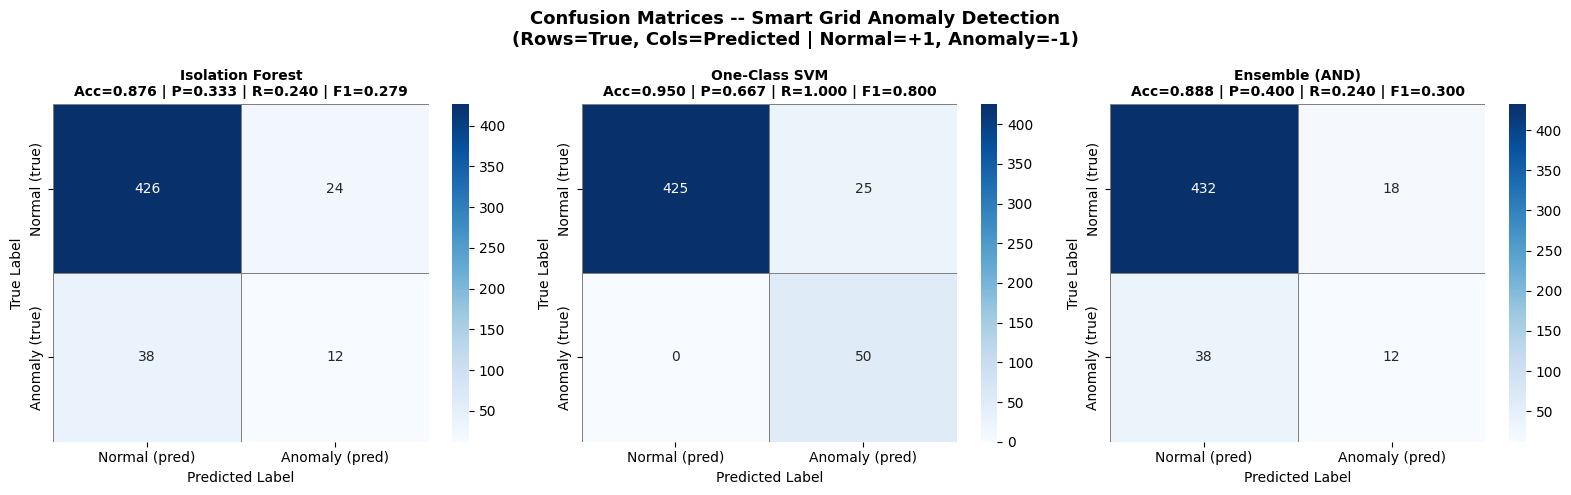

 Confusion matrices saved -> confusion_matrices.png

Interpretation:
  Isolation Forest -- higher Recall, may have more FP (false alarms)
  One-Class SVM    -- conservative boundaries, fewer FP but possibly more FN
  Ensemble (AND)   -- maximises Precision; best for operator alert quality
  For grid safety, Recall matters most -- missed faults are costly


In [ ]:
# ── Cell 12: ML Evaluation -- Confusion Matrix + Full Metrics ─────────────
np.random.seed(42)
n_eval = 500; n_anom = 50

X_eval  = X_scaled[:n_eval].copy()
y_true  = np.ones(n_eval)          # 1 = normal
anom_idx = np.random.choice(n_eval, n_anom, replace=False)
X_eval[anom_idx, 0] += 5           # voltage spike
X_eval[anom_idx, 2] -= 4           # power factor drop
y_true[anom_idx] = -1              # -1 = anomaly

y_pred_if  = iso_forest.predict(X_eval)
y_pred_svm = ocsvm.predict(X_eval)
y_pred_ens = np.where((y_pred_if == -1) & (y_pred_svm == -1), -1, 1)

# ── Metrics table ──────────────────────────────────────────────────────────
print('=' * 70)
print(f'{"MODEL":<25}  {"ACC":>5}  {"PREC":>5}  {"REC":>5}  {"F1":>5}')
print('-' * 70)

results = {}
for name, y_pred in [('Isolation Forest', y_pred_if),
                      ('One-Class SVM',    y_pred_svm),
                      ('Ensemble (AND)',   y_pred_ens)]:
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, pos_label=-1, zero_division=0)
    rec  = recall_score(y_true, y_pred, pos_label=-1, zero_division=0)
    f1   = f1_score(y_true, y_pred, pos_label=-1, zero_division=0)
    results[name] = (acc, prec, rec, f1)
    print(f'{name:<25}  {acc:>5.3f}  {prec:>5.3f}  {rec:>5.3f}  {f1:>5.3f}')

print('=' * 70)

# ── Classification reports ────────────────────────────────────────────────
for name, y_pred in [('Isolation Forest', y_pred_if),
                      ('One-Class SVM',    y_pred_svm),
                      ('Ensemble (AND)',   y_pred_ens)]:
    print(f'\n-- {name} --')
    print(classification_report(y_true, y_pred,
                                 target_names=['Normal (+1)', 'Anomaly (-1)'],
                                 labels=[1, -1], zero_division=0))

# ── Confusion matrix visualisation ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    'Confusion Matrices -- Smart Grid Anomaly Detection\n'
    '(Rows=True, Cols=Predicted | Normal=+1, Anomaly=-1)',
    fontsize=13, fontweight='bold'
)
for ax, (name, y_pred) in zip(axes, [
    ('Isolation Forest', y_pred_if),
    ('One-Class SVM',    y_pred_svm),
    ('Ensemble (AND)',   y_pred_ens)
]):
    cm = confusion_matrix(y_true, y_pred, labels=[1, -1])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal (pred)', 'Anomaly (pred)'],
                yticklabels=['Normal (true)', 'Anomaly (true)'],
                linewidths=0.5, linecolor='gray')
    acc, prec, rec, f1 = results[name]
    ax.set_title(f'{name}\nAcc={acc:.3f} | P={prec:.3f} | R={rec:.3f} | F1={f1:.3f}',
                 fontsize=10, fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Confusion matrices saved -> confusion_matrices.png')

print()
print('Interpretation:')
print('  Isolation Forest -- higher Recall, may have more FP (false alarms)')
print('  One-Class SVM    -- conservative boundaries, fewer FP but possibly more FN')
print('  Ensemble (AND)   -- maximises Precision; best for operator alert quality')
print('  For grid safety, Recall matters most -- missed faults are costly')


In [ ]:
# ── Cell 13: Write Streamlit App File ───────────────────────────────────────
STREAMLIT_SRC = 'import streamlit as st\nimport pandas as pd\nimport numpy as np\nimport plotly.graph_objects as go\nimport plotly.express as px\nfrom plotly.subplots import make_subplots\nimport time, os, json\nfrom calendar import month_name\n\nst.set_page_config(\n    page_title="GridSense — Smart Grid Monitor",\n    page_icon="⚡",\n    layout="wide",\n    initial_sidebar_state="expanded"\n)\n\nCSS = \'\'\'\n<style>\n@import url(\'https://fonts.googleapis.com/css2?family=Rajdhani:wght@500;700&family=Inter:wght@300;400;500;600&display=swap\');\nhtml, body, [class*="css"] { font-family: \'Inter\', sans-serif; background-color: #0a0e1a; color: #e2e8f0; }\nsection[data-testid="stSidebar"] { background: linear-gradient(180deg,#0d1220 0%,#111827 100%); border-right:1px solid rgba(99,179,237,.15); }\n#MainMenu, footer, header { visibility: hidden; }\ndiv[data-testid="metric-container"] {\n  background: linear-gradient(135deg,#111827 0%,#1a2035 100%);\n  border:1px solid rgba(99,179,237,.2); border-radius:12px; padding:1rem 1.25rem;\n  box-shadow:0 0 20px rgba(99,179,237,.05),inset 0 1px 0 rgba(255,255,255,.05);\n  transition:border-color .2s;\n}\ndiv[data-testid="metric-container"]:hover { border-color:rgba(99,179,237,.5); box-shadow:0 0 30px rgba(99,179,237,.12); }\ndiv[data-testid="metric-container"] label { color:#718096!important; font-size:.72rem!important; letter-spacing:.1em; text-transform:uppercase; font-weight:500; }\ndiv[data-testid="metric-container"] [data-testid="stMetricValue"] { color:#e2e8f0!important; font-family:\'Rajdhani\',sans-serif!important; font-size:2rem!important; font-weight:700; }\ndiv[data-baseweb="tab-list"] { background:transparent; border-bottom:1px solid rgba(99,179,237,.15); gap:.25rem; }\ndiv[data-baseweb="tab"] { background:transparent!important; color:#718096!important; font-size:.82rem; font-weight:500; letter-spacing:.05em; text-transform:uppercase; border-radius:6px 6px 0 0; padding:.5rem 1rem; border:none!important; transition:all .2s; }\ndiv[data-baseweb="tab"]:hover { color:#90cdf4!important; background:rgba(99,179,237,.08)!important; }\ndiv[data-baseweb="tab"][aria-selected="true"] { color:#63b3ed!important; background:rgba(99,179,237,.12)!important; border-bottom:2px solid #63b3ed!important; }\n.alert-card { background:linear-gradient(135deg,#1a1f35 0%,#1e2540 100%); border-left:3px solid #63b3ed; border-radius:8px; padding:.75rem 1rem; margin-bottom:.5rem; font-size:.85rem; line-height:1.5; }\n.alert-critical { border-left-color:#fc8181; background:linear-gradient(135deg,#2d1515 0%,#3d1c1c 100%); }\n.alert-high     { border-left-color:#f6ad55; background:linear-gradient(135deg,#2d2015 0%,#3d2a1a 100%); }\n.alert-medium   { border-left-color:#f6e05e; background:linear-gradient(135deg,#2d2a15 0%,#3d3620 100%); }\n.alert-low      { border-left-color:#68d391; background:linear-gradient(135deg,#152d1e 0%,#1e3d2a 100%); }\n.status-badge { display:inline-block; padding:2px 10px; border-radius:999px; font-size:.7rem; font-weight:600; letter-spacing:.06em; text-transform:uppercase; }\n.badge-live { background:rgba(72,187,120,.15); color:#68d391; border:1px solid rgba(72,187,120,.3); }\n.badge-critical { background:rgba(252,129,129,.15); color:#fc8181; border:1px solid rgba(252,129,129,.3); }\n.section-header { font-family:\'Rajdhani\',sans-serif; font-size:1.1rem; font-weight:700; color:#90cdf4; letter-spacing:.08em; text-transform:uppercase; margin:1.5rem 0 .75rem 0; padding-bottom:.4rem; border-bottom:1px solid rgba(99,179,237,.15); }\n.chart-card { background:linear-gradient(135deg,#111827 0%,#1a2035 100%); border:1px solid rgba(99,179,237,.12); border-radius:12px; padding:1rem 1.2rem 0.5rem 1.2rem; margin-bottom:1rem; }\n.grid-header { background:linear-gradient(90deg,#0d1220 0%,#111827 60%,#0d1a2e 100%); border:1px solid rgba(99,179,237,.18); border-radius:14px; padding:1.25rem 2rem; margin-bottom:1.5rem; display:flex; align-items:center; justify-content:space-between; }\n</style>\n\'\'\'\nst.markdown(CSS, unsafe_allow_html=True)\n\n@st.cache_data\ndef load_data():\n    return pd.read_csv("grid_data_for_streamlit.csv", index_col=0, parse_dates=True)\n\n@st.cache_data\ndef load_alerts():\n    if os.path.exists("alerts_log.csv"):\n        return pd.read_csv("alerts_log.csv")\n    return pd.DataFrame()\n\ndf       = load_data()\nalert_df = load_alerts()\nTH = json.loads(open("grid_thresholds.json").read())\n\n# ── Sidebar ───────────────────────────────────────────────────────────────────\nst.sidebar.markdown("## ⚡ GridSense")\nst.sidebar.markdown("<p style=\'color:#718096;font-size:.75rem;margin-top:-.5rem;letter-spacing:.08em\'>SMART GRID IIoT MONITOR</p>", unsafe_allow_html=True)\nst.sidebar.markdown("---")\n\n# ── Month selector ────────────────────────────────────────────────────────────\navailable_months = sorted(df.index.to_period("M").unique())\nmonth_labels     = [f"{month_name[p.month]} {p.year}" for p in available_months]\nmonth_map        = {lbl: p for lbl, p in zip(month_labels, available_months)}\n\nst.sidebar.markdown("**🗓️ View Mode**")\nview_mode = st.sidebar.radio("", ["Month", "Custom Range"], label_visibility="collapsed")\n\nif view_mode == "Month":\n    default_idx = len(month_labels) - 1\n    sel_month_lbl = st.sidebar.selectbox("**📅 Select Month**", month_labels, index=default_idx)\n    sel_period    = month_map[sel_month_lbl]\n    mask = df.index.to_period("M") == sel_period\n    view_label = sel_month_lbl\nelse:\n    date_min = df.index.min().date()\n    date_max = df.index.max().date()\n    st.sidebar.markdown("**📅 Date Range**")\n    d1, d2   = st.sidebar.date_input("", [date_min, date_max], min_value=date_min, max_value=date_max, label_visibility="collapsed")\n    mask     = (df.index.date >= d1) & (df.index.date <= d2)\n    view_label = f"{d1} to {d2}"\n\nst.sidebar.markdown("**🚨 Severity**")\nsev_filter = st.sidebar.multiselect("", ["CRITICAL","HIGH","MEDIUM","LOW"], default=["CRITICAL","HIGH","MEDIUM","LOW"], label_visibility="collapsed")\nst.sidebar.markdown("**🔍 Source**")\nsrc_filter = st.sidebar.multiselect("", ["rule","statistical","ML"], default=["rule","statistical","ML"], label_visibility="collapsed")\nst.sidebar.markdown("---")\nauto_ref = st.sidebar.checkbox("🔄 Auto-refresh (5s)", value=False)\nif auto_ref:\n    time.sleep(5)\n    st.rerun()\nst.sidebar.markdown("---")\nst.sidebar.caption(f"📊 Data: {len(df):,} rows")\nst.sidebar.caption(f"🔔 Alerts: {len(alert_df):,}")\n\n# ── Apply date filter ─────────────────────────────────────────────────────────\ndff     = df[mask]\nens_col = "Ensemble_Anomaly"\nan_cnt  = int(dff[ens_col].sum()) if ens_col in dff else 0\ncrit_alerts = len(alert_df[alert_df["Severity"] == "CRITICAL"]) if not alert_df.empty and "Severity" in alert_df else 0\n\n# ── Header banner ──────────────────────────────────────────────────────────────\nst.markdown(\n    f\'<div class="grid-header">\'\n    f\'<div><div style="font-family:Rajdhani,sans-serif;font-size:1.8rem;font-weight:700;color:#e2e8f0">⚡ GridSense</div>\'\n    f\'<div style="color:#718096;font-size:.75rem;letter-spacing:.12em;text-transform:uppercase;margin-top:2px">Smart Grid IIoT Monitoring · ML Anomaly Detection · Real-Time Alerts</div></div>\'\n    f\'<div style="display:flex;gap:.75rem;align-items:center">\'\n    f\'<span class="status-badge badge-live">● LIVE</span>\'\n    + (f\'<span class="status-badge badge-critical">⚠ {crit_alerts} CRITICAL</span>\' if crit_alerts else \'\')\n    + f\'<span style="color:#718096;font-size:.75rem;padding-left:.5rem">📅 {view_label}</span>\'\n    + \'</div></div>\',\n    unsafe_allow_html=True\n)\n\n# ── KPI strip ──────────────────────────────────────────────────────────────────\nk1,k2,k3,k4,k5,k6 = st.columns(6)\nk1.metric("📡 Data Points",    f"{len(dff):,}")\nk2.metric("🤖 ML Anomalies",   f"{an_cnt}")\nk3.metric("⚡ Avg Voltage",    f"{dff[\'Voltage_V\'].mean():.1f} V")\nk4.metric("🌡️ Avg Temp",       f"{dff[\'Temperature_C\'].mean():.1f} °C")\nk5.metric("💡 Avg Power",      f"{dff[\'Active_Power_kW\'].mean():.1f} kW")\nk6.metric("📊 Avg Efficiency", f"{dff[\'Energy_Efficiency_Score\'].mean():.2f}")\nst.markdown("---")\n\n# ── Shared layout config ───────────────────────────────────────────────────────\nDARK_LAYOUT = dict(\n    template="plotly_dark",\n    paper_bgcolor="rgba(0,0,0,0)",\n    plot_bgcolor="rgba(17,24,39,0.5)",\n    font=dict(family="Inter", color="#a0aec0", size=12),\n    margin=dict(t=50, b=40, l=60, r=30),\n    xaxis=dict(\n        gridcolor="rgba(99,179,237,0.07)",\n        linecolor="rgba(99,179,237,0.15)",\n        tickfont=dict(size=11, color="#718096"),\n        title_font=dict(size=12, color="#90cdf4"),\n    ),\n    yaxis=dict(\n        gridcolor="rgba(99,179,237,0.07)",\n        linecolor="rgba(99,179,237,0.15)",\n        tickfont=dict(size=11, color="#718096"),\n        title_font=dict(size=12, color="#90cdf4"),\n    ),\n    legend=dict(\n        bgcolor="rgba(13,18,32,0.7)",\n        bordercolor="rgba(99,179,237,0.2)",\n        borderwidth=1,\n        font=dict(size=11, color="#a0aec0"),\n        orientation="h",\n        yanchor="bottom", y=1.02,\n        xanchor="right", x=1,\n    ),\n    hoverlabel=dict(\n        bgcolor="#1a2035",\n        bordercolor="rgba(99,179,237,0.3)",\n        font=dict(size=12, color="#e2e8f0"),\n    ),\n)\n\ndef styled_fig(title="", height=320, yaxis_title=""):\n    fig = go.Figure()\n    layout = {**DARK_LAYOUT}\n    layout["title"] = dict(\n        text=title,\n        font=dict(family="Rajdhani", size=15, color="#90cdf4"),\n        x=0.01, y=0.97, xanchor="left"\n    )\n    layout["height"] = height\n    if yaxis_title:\n        layout["yaxis"] = {**DARK_LAYOUT["yaxis"], "title": yaxis_title}\n    fig.update_layout(**layout)\n    return fig\n\n# ── Anomaly timestamps ─────────────────────────────────────────────────────────\nan_ts = dff[dff.get(ens_col, pd.Series(0, index=dff.index)) == 1].index if ens_col in dff else []\n\ndef add_anomaly_markers(fig, col, an_ts, dff):\n    if len(an_ts):\n        m = dff.index.isin(an_ts)\n        fig.add_trace(go.Scatter(\n            x=dff.index[m], y=dff[col][m], mode="markers",\n            marker=dict(color="#fc8181", size=8, symbol="circle",\n                        line=dict(width=2, color="#fc8181"),\n                        opacity=0.85),\n            name="🤖 ML Anomaly", showlegend=True\n        ))\n\ndef add_hlines(fig, hi, lo):\n    if hi:\n        fig.add_hline(y=hi, line_dash="dot", line_color="rgba(252,129,129,0.5)",\n                      line_width=1.5,\n                      annotation_text="Upper limit", annotation_position="top right",\n                      annotation_font=dict(color="rgba(252,129,129,0.8)", size=10))\n    if lo:\n        fig.add_hline(y=lo, line_dash="dot", line_color="rgba(246,173,85,0.5)",\n                      line_width=1.5,\n                      annotation_text="Lower limit", annotation_position="bottom right",\n                      annotation_font=dict(color="rgba(246,173,85,0.8)", size=10))\n\n# ════════════════════════════════════════════════════════════════════════════\ntabs = st.tabs(["🗂️ Overview", "📡 Monitoring", "⚡ Power & Energy", "🌿 Renewables", "🤖 ML Anomalies", "🚨 Alerts"])\n\n# ── Tab 0: OVERVIEW — Master multi-param chart with full hover info ────────────\nwith tabs[0]:\n    st.markdown(\'<div class="section-header">All Parameters — Interactive Overview</div>\', unsafe_allow_html=True)\n    st.caption("Hover over any point to see all sensor readings at that timestamp. Anomaly regions are shaded red. Toggle traces via the legend.")\n\n    OVERVIEW_PARAMS = [\n        ("Voltage_V",                 "⚡ Voltage (V)",          "#63b3ed"),\n        ("Current_A",                 "🔌 Current (A)",           "#f6ad55"),\n        ("Power_Factor",              "📐 Power Factor",          "#68d391"),\n        ("Temperature_C",             "🌡️ Temperature (°C)",      "#fc8181"),\n        ("Grid_Frequency_Hz",         "〰️ Frequency (Hz)",        "#b794f4"),\n        ("Active_Power_kW",           "💡 Active Power (kW)",     "#e9d8fd"),\n        ("Reactive_Power_kVAR",       "🔄 Reactive Power (kVAR)", "#76e4f7"),\n        ("Power_Consumption_kWh",     "🔋 Consumption (kWh)",     "#fbb6ce"),\n        ("Solar_Power_Generation_kW", "☀️ Solar Gen (kW)",        "#FDB827"),\n        ("Wind_Power_Generation_kW",  "💨 Wind Gen (kW)",         "#56b3e9"),\n        ("Energy_Efficiency_Score",   "📊 Efficiency Score",      "#f6e05e"),\n    ]\n\n    hover_cols = [c for c, _, _ in OVERVIEW_PARAMS if c in dff.columns]\n    hover_df   = dff[hover_cols].copy()\n    if ens_col in dff.columns:\n        hover_df["_anom"] = dff[ens_col].values\n    else:\n        hover_df["_anom"] = 0\n\n    unit_map = {\n        "Voltage_V": "V", "Current_A": "A", "Power_Factor": "",\n        "Temperature_C": "°C", "Grid_Frequency_Hz": "Hz",\n        "Active_Power_kW": "kW", "Reactive_Power_kVAR": "kVAR",\n        "Power_Consumption_kWh": "kWh", "Solar_Power_Generation_kW": "kW",\n        "Wind_Power_Generation_kW": "kW", "Energy_Efficiency_Score": "",\n    }\n    label_map = {c: lbl for c, lbl, _ in OVERVIEW_PARAMS}\n\n    def _ascii_label(s):\n        return \'\'.join(c if ord(c) < 0x2500 else \'\' for c in s).strip()\n    safe_label_map = {c: _ascii_label(lbl) for c, lbl in label_map.items()}\n\n    def build_hover_text(row):\n        lines = [f"<b>{row.name.strftime(\'%d %b %Y  %H:%M\')}</b>"]\n        if row.get("_anom", 0) == 1:\n            lines.append("<b style=\'color:#fc8181\'>[!!] ML ANOMALY DETECTED</b>")\n        lines.append("-" * 22)\n        for c in hover_cols:\n            val = row.get(c, float("nan"))\n            if not np.isnan(val):\n                unit = unit_map.get(c, "")\n                lbl  = safe_label_map.get(c, c)\n                lines.append(f"{lbl}: <b>{val:.3f}{\' \'+unit if unit else \'\'}</b>")\n        return "<br>".join(lines)\n\n    hover_texts = hover_df.apply(build_hover_text, axis=1).tolist()\n\n    fig_ov = go.Figure()\n    layout_ov = {**DARK_LAYOUT}\n    layout_ov["title"] = dict(\n        text="📊 All Grid Parameters — Normalised Overlay (hover any point for all raw values)",\n        font=dict(family="Rajdhani", size=16, color="#90cdf4"),\n        x=0.01, y=0.97, xanchor="left"\n    )\n    layout_ov["height"] = 540\n    layout_ov["yaxis"]  = {**DARK_LAYOUT["yaxis"], "title": "Normalised Value (0–1)", "range": [-0.05, 1.15]}\n    layout_ov["xaxis"]  = {**DARK_LAYOUT["xaxis"]}\n    layout_ov["legend"] = {\n        "bgcolor": "rgba(13,18,32,0.85)",\n        "bordercolor": "rgba(99,179,237,0.2)",\n        "borderwidth": 1,\n        "font": dict(size=10, color="#a0aec0"),\n        "orientation": "v",\n        "yanchor": "top", "y": 1,\n        "xanchor": "left", "x": 1.01,\n    }\n    layout_ov["margin"] = dict(t=60, b=45, l=65, r=210)\n    fig_ov.update_layout(**layout_ov)\n\n    for col, lbl, clr in OVERVIEW_PARAMS:\n        if col not in dff.columns:\n            continue\n        s = dff[col]\n        mn, mx = s.min(), s.max()\n        norm = (s - mn) / (mx - mn + 1e-9)\n        fig_ov.add_trace(go.Scatter(\n            x=dff.index,\n            y=norm,\n            mode="lines",\n            name=lbl,\n            line=dict(color=clr, width=1.6),\n            opacity=0.85,\n            hovertext=hover_texts,\n            hoverinfo="text",\n            hoverlabel=dict(bgcolor="#1a2035", bordercolor=clr,\n                            font=dict(size=12, color="#e2e8f0")),\n        ))\n\n    # Red shaded anomaly bands\n    if ens_col in dff.columns and an_cnt > 0:\n        an_idx = dff.index[dff[ens_col] == 1]\n        for ts in an_idx:\n            fig_ov.add_vrect(\n                x0=ts, x1=ts + pd.Timedelta(minutes=30),\n                fillcolor="rgba(252,129,129,0.09)",\n                line_width=0,\n                layer="below"\n            )\n        fig_ov.add_trace(go.Scatter(\n            x=[None], y=[None], mode="markers",\n            marker=dict(color="rgba(252,129,129,0.5)", size=10, symbol="square"),\n            name="🤖 Anomaly band"\n        ))\n\n    st.plotly_chart(fig_ov, use_container_width=True)\n    st.info("💡 All signals are **normalised to 0–1** so every parameter fits on one axis. The absolute raw values — voltage, current, temperature, etc. — appear in the hover tooltip. Red bands mark ML-detected anomaly windows.")\n\n    # ── Monthly summary table ──────────────────────────────────────────────────\n    st.markdown(\'<div class="section-header" style="margin-top:1.2rem">Monthly Averages</div>\', unsafe_allow_html=True)\n    summary_cols = ["Voltage_V", "Current_A", "Temperature_C", "Active_Power_kW",\n                    "Power_Consumption_kWh", "Energy_Efficiency_Score"]\n    avail_sum = [c for c in summary_cols if c in df.columns]\n    monthly = df[avail_sum].resample("ME").mean().round(3)\n    monthly.index = monthly.index.strftime("%b %Y")\n    if ens_col in df.columns:\n        monthly["ML Anomalies"] = df[ens_col].resample("ME").sum().astype(int).values\n    st.dataframe(monthly.style.background_gradient(cmap="Blues", axis=0), use_container_width=True)\n\n# ── Tab 1: Monitoring ──────────────────────────────────────────────────────────\nwith tabs[1]:\n    st.markdown(\'<div class="section-header">Real-Time Parameter Monitoring</div>\', unsafe_allow_html=True)\n\n    PARAM_CFG = [\n        ("Voltage_V",         "⚡ Voltage",       TH.get("voltage_high"),     TH.get("voltage_low"),      "#63b3ed",  "rgba(99,179,237,0.08)",    "Voltage (V)"),\n        ("Current_A",         "🔌 Current",       TH.get("current_high"),     None,                        "#f6ad55",  "rgba(246,173,85,0.08)",    "Current (A)"),\n        ("Power_Factor",      "📐 Power Factor",  None,                        TH.get("power_factor_low"), "#68d391",  "rgba(104,211,145,0.08)",   "Power Factor"),\n        ("Temperature_C",     "🌡️ Temperature",   TH.get("temp_high"),        None,                        "#fc8181",  "rgba(252,129,129,0.08)",   "Temp (°C)"),\n        ("Grid_Frequency_Hz", "〰️ Frequency",     TH.get("freq_high"),        TH.get("freq_low"),         "#b794f4",  "rgba(183,148,244,0.08)",   "Frequency (Hz)"),\n    ]\n\n    pairs = [(PARAM_CFG[i], PARAM_CFG[i+1]) for i in range(0, len(PARAM_CFG)-1, 2)]\n    last  = PARAM_CFG[-1] if len(PARAM_CFG) % 2 else None\n\n    for left_cfg, right_cfg in pairs:\n        c1, c2 = st.columns(2, gap="medium")\n        for cfg, container in [(left_cfg, c1), (right_cfg, c2)]:\n            col, label, hi, lo, clr, fill, yunit = cfg\n            if col not in dff.columns:\n                continue\n            fig = styled_fig(label, height=300, yaxis_title=yunit)\n            fig.add_trace(go.Scatter(\n                x=dff.index, y=dff[col], mode="lines",\n                line=dict(color=clr, width=2),\n                fill="tozeroy", fillcolor=fill,\n                name=label, showlegend=False,\n                hovertemplate=f"<b>%{{x|%d %b %H:%M}}</b><br>{yunit}: %{{y:.3f}}<extra></extra>"\n            ))\n            add_anomaly_markers(fig, col, an_ts, dff)\n            add_hlines(fig, hi, lo)\n            container.plotly_chart(fig, use_container_width=True)\n\n    if last:\n        col, label, hi, lo, clr, fill, yunit = last\n        if col in dff.columns:\n            fig = styled_fig(label, height=280, yaxis_title=yunit)\n            fig.add_trace(go.Scatter(\n                x=dff.index, y=dff[col], mode="lines",\n                line=dict(color=clr, width=2),\n                fill="tozeroy", fillcolor=fill,\n                name=label, showlegend=False,\n                hovertemplate=f"<b>%{{x|%b %d %H:%M}}</b><br>{yunit}: %{{y:.3f}}<extra></extra>"\n            ))\n            add_anomaly_markers(fig, col, an_ts, dff)\n            add_hlines(fig, hi, lo)\n            st.plotly_chart(fig, use_container_width=True)\n\n# ── Tab 2: Power & Energy ──────────────────────────────────────────────────────\nwith tabs[2]:\n    st.markdown(\'<div class="section-header">Power & Energy Analytics</div>\', unsafe_allow_html=True)\n\n    POWER_CFG = [\n        ("Active_Power_kW",       "💡 Active Power",       "#b794f4", "rgba(183,148,244,0.10)", "Active Power (kW)"),\n        ("Reactive_Power_kVAR",   "🔄 Reactive Power",     "#63b3ed", "rgba(99,179,237,0.10)",  "Reactive Power (kVAR)"),\n        ("Power_Consumption_kWh", "🔋 Energy Consumption", "#f6ad55", "rgba(246,173,85,0.10)",  "Consumption (kWh)"),\n        ("Grid_Frequency_Hz",     "〰️ Grid Frequency",     "#68d391", "rgba(104,211,145,0.10)", "Frequency (Hz)"),\n    ]\n\n    for i in range(0, len(POWER_CFG), 2):\n        row_cfgs = POWER_CFG[i:i+2]\n        cols = st.columns(len(row_cfgs), gap="medium")\n        for cfg, container in zip(row_cfgs, cols):\n            col, label, clr, fill, yunit = cfg\n            if col not in dff.columns:\n                continue\n            fig = styled_fig(label, height=300, yaxis_title=yunit)\n            fig.add_trace(go.Scatter(\n                x=dff.index, y=dff[col], mode="lines",\n                line=dict(color=clr, width=2),\n                fill="tozeroy", fillcolor=fill,\n                name=label, showlegend=False,\n                hovertemplate=f"<b>%{{x|%d %b %H:%M}}</b><br>{yunit}: %{{y:.2f}}<extra></extra>"\n            ))\n            container.plotly_chart(fig, use_container_width=True)\n\n    if "Energy_Efficiency_Score" in dff.columns:\n        st.markdown(\'<div class="section-header" style="margin-top:.5rem">Efficiency Trend</div>\', unsafe_allow_html=True)\n        fig_eff = styled_fig("📊 Energy Efficiency Score Over Time", height=280, yaxis_title="Efficiency Score")\n        fig_eff.add_trace(go.Scatter(\n            x=dff.index, y=dff["Energy_Efficiency_Score"], mode="lines",\n            line=dict(color="#f6e05e", width=2),\n            fill="tozeroy", fillcolor="rgba(246,224,94,0.08)",\n            name="Efficiency", showlegend=False,\n            hovertemplate="<b>%{x|%d %b %H:%M}</b><br>Score: %{y:.3f}<extra></extra>"\n        ))\n        st.plotly_chart(fig_eff, use_container_width=True)\n\n# ── Tab 3: Renewables ─────────────────────────────────────────────────────────\nwith tabs[3]:\n    st.markdown(\'<div class="section-header">Renewable Energy Generation</div>\', unsafe_allow_html=True)\n\n    solar_ok = "Solar_Power_Generation_kW" in dff.columns\n    wind_ok  = "Wind_Power_Generation_kW"  in dff.columns\n\n    fig_re = styled_fig("☀️ Solar & 💨 Wind Generation", height=380, yaxis_title="Power (kW)")\n    if solar_ok:\n        fig_re.add_trace(go.Scatter(\n            x=dff.index, y=dff["Solar_Power_Generation_kW"],\n            fill="tozeroy", name="☀️ Solar (kW)",\n            line=dict(color="#FDB827", width=2),\n            fillcolor="rgba(253,184,39,0.15)",\n            hovertemplate="<b>%{x|%d %b %H:%M}</b><br>Solar: %{y:.1f} kW<extra></extra>"\n        ))\n    if wind_ok:\n        fig_re.add_trace(go.Scatter(\n            x=dff.index, y=dff["Wind_Power_Generation_kW"],\n            fill="tonexty", name="💨 Wind (kW)",\n            line=dict(color="#56b3e9", width=2),\n            fillcolor="rgba(86,179,233,0.15)",\n            hovertemplate="<b>%{x|%d %b %H:%M}</b><br>Wind: %{y:.1f} kW<extra></extra>"\n        ))\n    st.plotly_chart(fig_re, use_container_width=True)\n\n    if solar_ok and wind_ok:\n        c_pie, c_stats = st.columns([1, 2], gap="large")\n        ts = dff["Solar_Power_Generation_kW"].sum()\n        tw = dff["Wind_Power_Generation_kW"].sum()\n\n        fp = go.Figure(go.Pie(\n            labels=["☀️ Solar", "💨 Wind"], values=[ts, tw], hole=0.6,\n            marker=dict(colors=["#FDB827", "#56b3e9"], line=dict(color="#0a0e1a", width=2)),\n            textfont=dict(size=12, color="#e2e8f0"),\n            hovertemplate="%{label}<br>%{value:.0f} kWh (%{percent})<extra></extra>"\n        ))\n        fp.update_layout(**{\n            **DARK_LAYOUT, "height": 300, "showlegend": True,\n            "title": dict(text="Renewable Mix", font=dict(family="Rajdhani", size=14, color="#90cdf4")),\n        })\n        c_pie.plotly_chart(fp, use_container_width=True)\n\n        total_active = dff["Active_Power_kW"].sum() if "Active_Power_kW" in dff.columns else 1\n        with c_stats:\n            st.markdown("<br>", unsafe_allow_html=True)\n            m1, m2 = st.columns(2)\n            m1.metric("☀️ Total Solar",      f"{ts/1000:.2f} MWh")\n            m2.metric("💨 Total Wind",       f"{tw/1000:.2f} MWh")\n            m1.metric("⚡ Combined",          f"{(ts+tw)/1000:.2f} MWh")\n            m2.metric("🌿 Renewables Share", f"{(ts+tw)/(total_active+0.001)*100:.1f}%")\n\n# ── Tab 4: ML Anomalies ───────────────────────────────────────────────────────\nwith tabs[4]:\n    st.markdown(\'<div class="section-header">ML Anomaly Detection</div>\', unsafe_allow_html=True)\n\n    m1, m2, m3 = st.columns(3)\n    m1.metric("🌳 Isolation Forest",  int((dff.get("IF_Anomaly",    pd.Series()) == -1).sum()))\n    m2.metric("🔵 One-Class SVM",     int((dff.get("OCSVM_Anomaly", pd.Series()) == -1).sum()))\n    m3.metric("🤖 Ensemble (AND)",    int(dff.get("Ensemble_Anomaly", pd.Series(0, index=dff.index)).sum()))\n    st.markdown("<br>", unsafe_allow_html=True)\n\n    if "IF_Score" in dff.columns:\n        fig_if = styled_fig("🤖 Isolation Forest Anomaly Score Over Time", height=320, yaxis_title="Anomaly Score")\n        fig_if.add_trace(go.Scatter(\n            x=dff.index, y=dff["IF_Score"], mode="lines",\n            line=dict(color="#f6ad55", width=1.8),\n            fill="tozeroy", fillcolor="rgba(246,173,85,0.10)",\n            name="IF Score", showlegend=False,\n            hovertemplate="<b>%{x|%d %b %H:%M}</b><br>Score: %{y:.4f}<extra></extra>"\n        ))\n        if ens_col in dff.columns:\n            ens_mask = dff[ens_col] == 1\n            if ens_mask.any():\n                fig_if.add_trace(go.Scatter(\n                    x=dff.index[ens_mask], y=dff["IF_Score"][ens_mask], mode="markers",\n                    marker=dict(color="#fc8181", size=8, symbol="circle",\n                                line=dict(width=1.5, color="#fc8181")),\n                    name="🤖 Ensemble Anomaly", showlegend=True\n                ))\n        st.plotly_chart(fig_if, use_container_width=True)\n\n        hdf = dff[["IF_Score"]].copy()\n        hdf["Hour"] = dff.index.hour\n        hdf["DoW"]  = dff.index.dayofweek\n        pivot = hdf.groupby(["DoW", "Hour"])["IF_Score"].mean().unstack(fill_value=0)\n        fh = px.imshow(\n            pivot, color_continuous_scale="RdYlGn_r",\n            labels=dict(x="Hour of Day", y="Day of Week", color="Avg Score"),\n            aspect="auto"\n        )\n        fh.update_yaxes(tickvals=list(range(7)),\n                        ticktext=["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])\n        fh.update_layout(**{\n            **DARK_LAYOUT, "height": 310,\n            "title": dict(text="🗓️ Anomaly Heatmap — Day × Hour", font=dict(family="Rajdhani", size=14, color="#90cdf4")),\n            "margin": dict(t=55, b=45, l=70, r=30),\n            "coloraxis_colorbar": dict(\n                tickfont=dict(color="#a0aec0", size=10),\n                title=dict(text="Score", font=dict(color="#90cdf4", size=11)),\n                len=0.85,\n            )\n        })\n        st.plotly_chart(fh, use_container_width=True)\n\n# ── Tab 5: Alerts ─────────────────────────────────────────────────────────────\nwith tabs[5]:\n    st.markdown(\'<div class="section-header">Alert Feed</div>\', unsafe_allow_html=True)\n\n    if not alert_df.empty:\n        fdf = alert_df.copy()\n        if sev_filter: fdf = fdf[fdf["Severity"].isin(sev_filter)]\n        if src_filter: fdf = fdf[fdf["Source"].isin(src_filter)]\n        fdf_sorted = fdf.sort_values("Sent_At", ascending=False).head(200)\n\n        SEV_ICON  = {"CRITICAL":"🔴","HIGH":"🟠","MEDIUM":"🟡","LOW":"🟢"}\n        SEV_CLASS = {"CRITICAL":"alert-critical","HIGH":"alert-high","MEDIUM":"alert-medium","LOW":"alert-low"}\n\n        for _, row in fdf_sorted.head(30).iterrows():\n            sev   = str(row.get("Severity",""))\n            icon  = SEV_ICON.get(sev,"⚪")\n            cls   = SEV_CLASS.get(sev,"")\n            param = str(row.get("Parameter","")).replace("_"," ")\n            atype = str(row.get("Alert_Type",""))\n            val   = row.get("Value","")\n            fix   = str(row.get("Suggested_Fix",""))\n            ts    = str(row.get("Sent_At",""))\n            st.markdown(\n                f\'<div class="alert-card {cls}">\'\n                f\'<strong>{icon} {atype}</strong> &nbsp;|&nbsp; <code>{param}</code> = <code>{val}</code>\'\n                f\'<br><span style="color:#718096;font-size:.78rem">🕐 {ts} &nbsp; 🛠️ {fix}</span>\'\n                f\'</div>\',\n                unsafe_allow_html=True\n            )\n\n        st.markdown("---")\n\n        COLORS = {\n            "CRITICAL":"#fc8181","HIGH":"#f6ad55","MEDIUM":"#f6e05e","LOW":"#68d391",\n            "rule":"#63b3ed","statistical":"#b794f4","ML":"#f6ad55"\n        }\n        a1, a2, a3 = st.columns(3, gap="medium")\n        for cn, cont, label in [("Severity",a1,"By Severity"),("Source",a2,"By Source"),("Alert_Type",a3,"By Type")]:\n            cnt = alert_df[cn].value_counts()\n            fp = go.Figure(go.Bar(\n                x=cnt.index, y=cnt.values,\n                marker=dict(\n                    color=[COLORS.get(str(x),"#718096") for x in cnt.index],\n                    line=dict(color="rgba(0,0,0,0.3)", width=1),\n                    opacity=0.85\n                ),\n                text=cnt.values, textposition="outside",\n                textfont=dict(color="#a0aec0", size=11),\n                hovertemplate="%{x}: %{y}<extra></extra>"\n            ))\n            fp.update_layout(**{\n                **DARK_LAYOUT, "height": 280, "showlegend": False,\n                "title": dict(text=label, font=dict(family="Rajdhani", size=13, color="#90cdf4")),\n                "margin": dict(t=45, b=35, l=40, r=20),\n                "yaxis": {**DARK_LAYOUT["yaxis"], "showgrid": False},\n                "bargap": 0.35,\n            })\n            cont.plotly_chart(fp, use_container_width=True)\n\n        csv_bytes = alert_df.to_csv(index=False).encode()\n        st.download_button("📥 Download Alert Log CSV", data=csv_bytes,\n                           file_name="alerts_log.csv", mime="text/csv")\n    else:\n        st.info("⚠️ No alerts yet. Run the simulation (Cell 9) first.")\n'
with open('streamlit_app.py', 'w') as f:
    f.write(STREAMLIT_SRC)
print('streamlit_app.py written')

streamlit_app.py written


In [ ]:
# ── Cell 14: Launch Streamlit Dashboard via pyngrok ─────────────────────
import subprocess, time, os, json

# Export data for Streamlit
df.to_csv('grid_data_for_streamlit.csv')
with open('grid_thresholds.json', 'w') as f:
    json.dump(THRESHOLDS, f)
print(' Data exported for Streamlit')

# Start Streamlit server
proc = subprocess.Popen(
    ['streamlit', 'run', 'streamlit_app.py',
     '--server.port', '8501',
     '--server.headless', 'true',
     '--server.enableCORS', 'false',
     '--server.enableXsrfProtection', 'false'],
    stdout=subprocess.PIPE, stderr=subprocess.PIPE
)
print('Streamlit starting (waiting 5s)...')
time.sleep(5)

# Create ngrok tunnel
if NGROK_AUTH_TOKEN:
    from pyngrok import ngrok, conf
    ngrok.kill()
    conf.get_default().auth_token = NGROK_AUTH_TOKEN
    url = ngrok.connect(8501)
    print(f'\n' + '='*60)
    print('STREAMLIT DASHBOARD IS LIVE!')
    print(f'Open this URL: {url}')
    print('='*60 + '\n')
else:
    print()
    print('NGROK_AUTH_TOKEN is empty. To get a public URL:')
    print('  1. Sign up free at https://ngrok.com')
    print('  2. Copy token from https://dashboard.ngrok.com/get-started/your-authtoken')
    print('  3. Paste into NGROK_AUTH_TOKEN in Cell 3 and re-run cells 3+14')
    print()
    print('Fallback -- run in a NEW cell to get a Colab proxy URL:')
    print('  from google.colab.output import eval_js')
    print('  print(eval_js("google.colab.kernel.proxyPort(8501)"))')

# Keep alive
try:
    while True:
        time.sleep(30)
except KeyboardInterrupt:
    proc.terminate()
    if NGROK_AUTH_TOKEN:
        ngrok.kill()
    print('Streamlit server stopped')


 Data exported for Streamlit
Streamlit starting (waiting 5s)...

STREAMLIT DASHBOARD IS LIVE!
Open this URL: NgrokTunnel: "https://zelma-memberless-sympathizingly.ngrok-free.dev" -> "http://localhost:8501"



In [ ]:
# ── Cell 15: Download All Output Files ──────────────────────────────────
import os
for fname in ['event_log.csv', 'event_log.xlsx',
              'alerts_log.csv', 'alerts_log.xlsx',
              'confusion_matrices.png']:
    if os.path.exists(fname):
        files.download(fname)
        print(f'Downloading {fname}')
    else:
        print(f'Not found: {fname} -- run earlier cells first')
